In [1]:
import os
import time
import bisect
import cv2
import numpy as np
import pandas as pd
import trackpy as tp
from scipy.signal import argrelmax

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IOfunctions as iof
import ChannelShapeAnalysis as csa
import DropletAnalysis as da

### 1: Open image sequence

In [2]:
#################
froot = r'D:\steaime\Data\Rheoflu\Wenyun_Tween80_0p56'
img_name = 'tween80_0p56_1000ulh_w4_20251103_20110_PM_20251103_020209_PM'
#################
fpath = os.path.join(froot, img_name + '.tif')
print('Image stack has shape: {0}'.format(iof.get_stack_shape(fpath)))
t0 = time.time()
bkg = iof.compute_background(fpath, avg_range=[0,1000])
print('Computing z average took {0:.2f} seconds'.format(time.time()-t0))

Image stack has shape: (13905, 436, 1280)
Computing z average took 3.57 seconds


### 2: Analyze channel shape

Constriction parameters:
omega = 654.2 [rad/s]
sigma = 13.459 [Pa]
phi   = 1.115 [rad]
q     = 8.925 [mm2/s]
L0    = 116.5 [um]
wavelength = 485.0 [um]


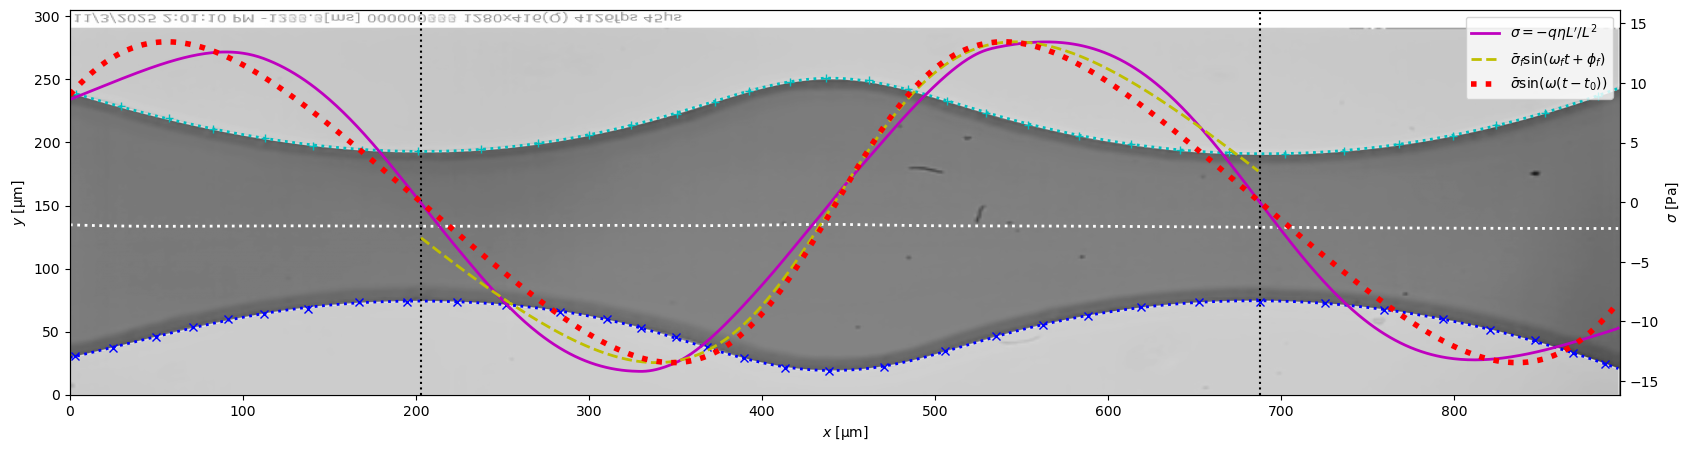

In [3]:
##########
px_size = 0.7 #um/px
fps = 4126    #1/s
eta = 0.058   #Pa.s
design_omega = 700
##########
params, shape, edges_um, chaxis_px, minpos_px = csa.AnalyzeChannelShape(bkg, os.path.join(froot, 'edge2_px.txt'), os.path.join(froot, 'edge1_px.txt'),
                                                                        px_size=px_size, design_omega=design_omega, eta=eta)

In [4]:
print('constriction positions [µm]: ' + str([pos*px_size for pos in minpos_px]))

constriction positions [µm]: [203.0, 687.4]


(<Figure size 1000x600 with 4 Axes>,
 array([<Axes: xlabel='$t$ [s]', ylabel='$L$ [µm]'>,
        <Axes: xlabel='$x$ [mm]'>], dtype=object),
 [<Axes: >, <Axes: ylabel='$\\sigma$ [Pa]'>])

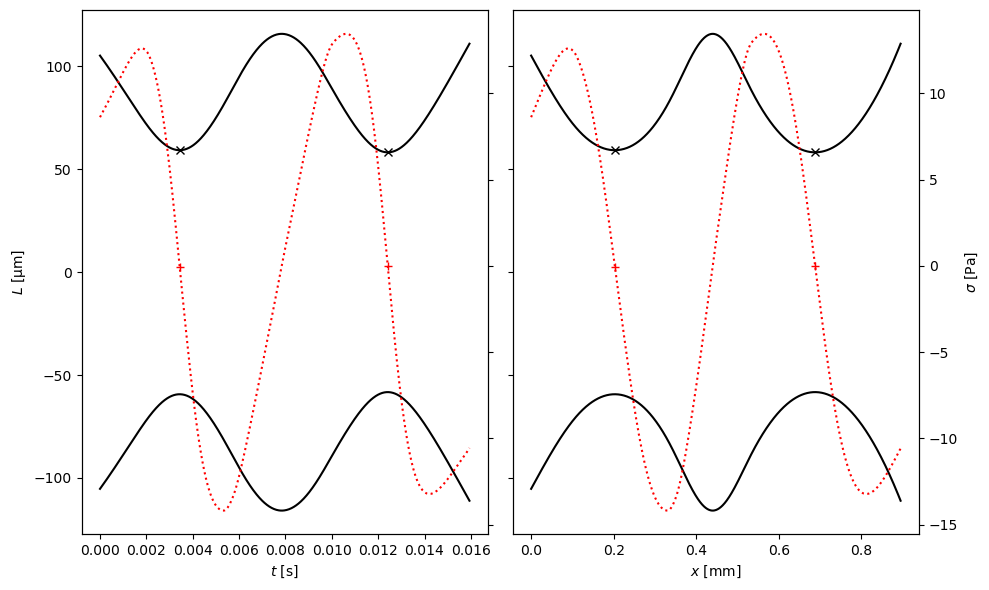

In [5]:
csa.plot_channel(*shape, q=params['q'], eta=eta)

### 3: Track droplets and compute stress

First, tune and test tracking parameters:

- ```[crop_margin_x, crop_margin_y]```: restrict search to a region around channel axis section between two constrictions 
- ```filter_range```: after locating and linking particles, disregard trajectories that are not fully contained in a narrower region
- ```filter_d```: search particles of a given diameter (in pixels, must be an odd integer)
- ```track_minmass, track_maxsize```: restrict locating features to masses and sizes smaller than given amounts
- ```search_range```: search range (in pixels) used by the linking algorithm
- ```track_zRange=[start_frame, end_frame]```: limit search to a substack. If ```None```, the entire stack is processed

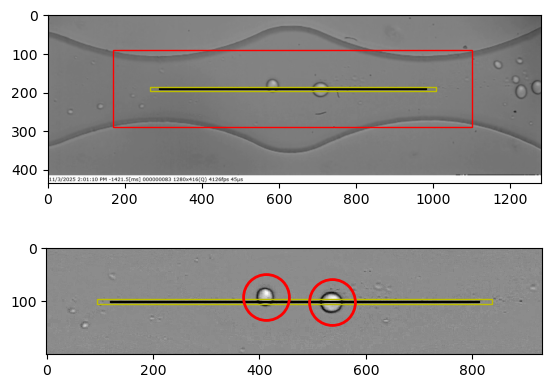

In [6]:
##########
test_frame = 83
filter_d = 33
crop_margin_x = 120
crop_size_y = 200
track_minmass = 4000
track_maxsize = 50
search_range = 70
filter_range = [25, 5]
bkgcorr_off = 150
track_zRange = None
##########

if track_zRange is None:
    track_zRange = [0, iof.get_stack_shape(fpath)[0]]
crop_ROI = [minpos_px[0] - crop_margin_x, chaxis_px - crop_size_y//2,
            minpos_px[1] + crop_margin_x, chaxis_px + crop_size_y//2]
full_frame = iof.get_single_frame(fpath, test_frame)
frame = iof.get_single_frame(fpath, test_frame, cropROI=crop_ROI, bkg=bkg, bkgcorr_offset=bkgcorr_off)
f_locate = tp.locate(frame, filter_d, minmass=track_minmass)
fig, ax = plt.subplots(nrows=2)
ax[0].imshow(full_frame, cmap='Greys_r', extent=(0, full_frame.shape[1], full_frame.shape[0], 0))
ax[0].add_patch(patches.Rectangle((crop_ROI[0], crop_ROI[1]), crop_ROI[2]-crop_ROI[0], crop_ROI[3]-crop_ROI[1], edgecolor='r', facecolor='none'))
ax[0].add_patch(patches.Rectangle((minpos_px[0], chaxis_px-1), minpos_px[1]-minpos_px[0], 2, edgecolor='k', facecolor='none'))
ax[0].add_patch(patches.Rectangle((minpos_px[0]-filter_range[0], chaxis_px-filter_range[1]), 
                                  minpos_px[1]-minpos_px[0]+2*filter_range[0], 2*filter_range[1], edgecolor='y', facecolor='none'))
tp.annotate(f_locate, frame, ax=ax[1], plot_style={'markersize': filter_d})
ax[1].add_patch(patches.Rectangle((crop_margin_x, crop_size_y//2), minpos_px[1]-minpos_px[0], 2, edgecolor='k', facecolor='none'))
ax[1].add_patch(patches.Rectangle((crop_margin_x-filter_range[0], crop_size_y//2-filter_range[1]), 
                                  minpos_px[1]-minpos_px[0]+2*filter_range[0], 2*filter_range[1], edgecolor='y', facecolor='none'))

Next, track particles across the entire stack

csv filename with track result already present: skip track calculation
26 particles have been tracked across the whole constriction


,Unnamed: 0,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle
0,18,189.310742,188.652477,10116.856516,8.447079,0.122245,37.144499,126676.0,NaN,28,1
1,14,189.536826,213.375469,9495.933606,8.217760,0.102693,35.253561,125941.0,NaN,29,1
2,15,189.830579,238.631432,9491.631643,8.158464,0.099042,36.119046,126259.0,NaN,30,1
3,16,190.060962,264.803371,9639.764696,8.102073,0.105718,37.801639,126584.0,NaN,31,1
4,18,190.312010,291.091378,9567.245967,8.101653,0.124746,37.759234,126644.0,NaN,32,1


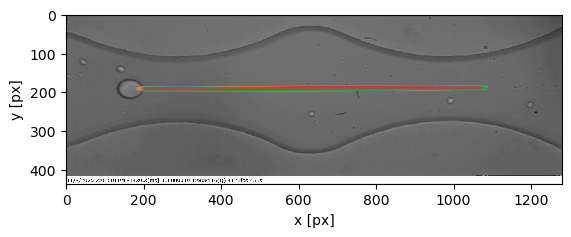

In [7]:
df_savepath = os.path.join(froot, img_name+'.csv')
force_track = False
if os.path.isfile(df_savepath) and not force_track:
    print('csv filename with track result already present: skip track calculation')
    track_df = pd.read_csv(df_savepath)
    PID_list = track_df['particle'].unique()
else:
    filter_range = [[minpos_px[0]-filter_range[0], minpos_px[1]+filter_range[0]],
                    [chaxis_px-filter_range[1], chaxis_px+filter_range[1]]]
    fstack = iof.get_stack(fpath, track_zRange, cropROI=crop_ROI, bkg=bkg, bkgcorr_offset=bkgcorr_off)
    track_df, PID_list = da.track_droplets(fstack, stack_offset=[track_zRange[0], crop_ROI[1], crop_ROI[0]], diameter=filter_d, minmass=track_minmass, 
                      maxsize=track_maxsize, filter_range=filter_range, search_range=search_range, link_memory=0, 
                        track_out_fpath=os.path.join(froot, img_name+'.h5'), track_procs=4, df_savepath=df_savepath)
print('{0} particles have been tracked across the whole constriction'.format(len(PID_list)))
fig, ax = plt.subplots()
tp.plot_traj(track_df, superimpose=iof.get_single_frame(fpath, 10), ax=ax, plot_style={'linewidth': 2})
track_df.head()

Now process particle trajectories, extract particle speed, $v_d(x)$, and compute stress on the particle: $\sigma_{ext}^d=\eta \partial v_d/\partial x$. First let's do that on one single track:

Maximum droplet speed:  vmax = 77591.4 µm/s
Frequency:             omega = 700.7 rad/s
Planar flow rate (est.):   q = 9.04 mm2/s
Reduced frequency (exp)  w/q = 77.486 1/mm2
Reduced frequency (params)   = 73.307 1/mm2
Real stress amplitude: sigma = 14.4 Pa
Stress amplitude (params): s = 13.5 Pa


Text(0, 0.5, '$\\sigma$ [Pa]')

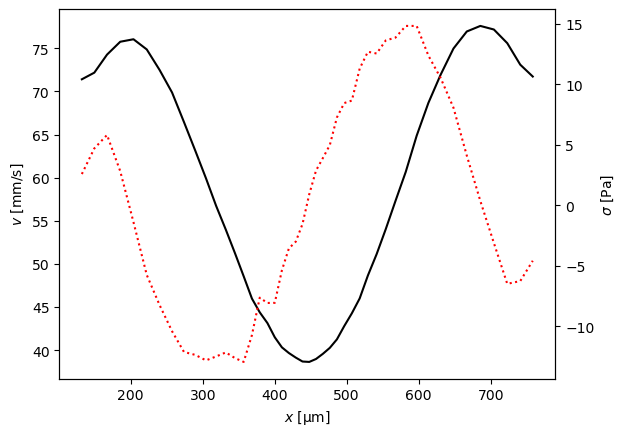

In [8]:
x_pos, v, stress = da.calc_droplet_stress(track_df[(track_df['particle'] == PID_list[0])]['x'], px_size=px_size, fps=fps, eta=eta, params=params, verbose=2)
fig, ax = plt.subplots()
ax.plot(x_pos*1e6, v*1e3, 'k-')
ax2 = ax.twinx()
ax2.plot(x_pos*1e6, stress, 'r:')
ax.set_ylabel(r'$v$ [mm/s]')
ax.set_xlabel(r'$x$ [µm]')
ax2.set_ylabel(r'$\sigma$ [Pa]')

Then on all tracks:

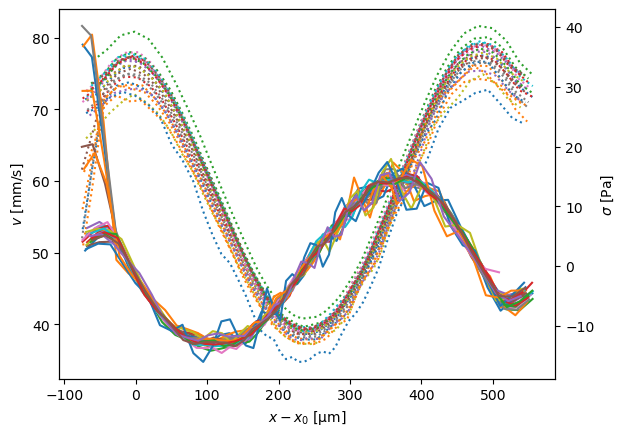

In [9]:
da.track_postproc(track_df, px_size=px_size, fps=fps, eta=eta, plot=True, verbose=0, x_off=minpos_px[0]*px_size)

### 4: Measure droplet deformation

First, find droplet edges with subpixel resolution, and filter resulting datapoints to only get the outer edge of the droplet

C:\Users\steaime\AppData\Local\Temp\ipykernel_10416\3737153260.py:11: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  drop_frame = int(track_df[(track_df['particle']==PID_list[0])]['frame'].iloc[[test_tidx]])


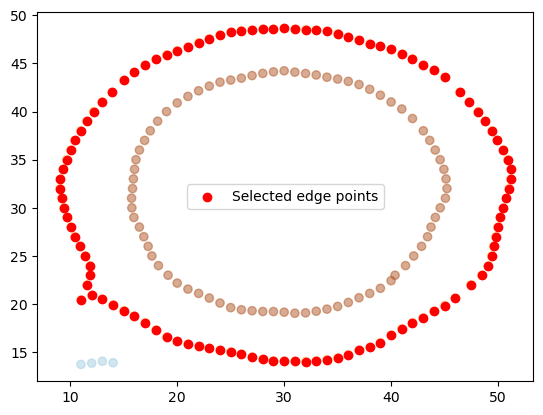

In [10]:
##########
test_tidx = 39
roi_size = 30
edge_blur = 2
dbscan_eps = 2.1
edge_thr = 5.5
edge_iterN = 4
filter_r_thr = 100
##########

drop_frame = int(track_df[(track_df['particle']==PID_list[0])]['frame'].iloc[[test_tidx]])
roi = track_df[(track_df['particle']==PID_list[0]) & (track_df['frame'] == drop_frame)]
xloc, yloc = int(roi["x"].iloc[0]), int(roi["y"].iloc[0])
drop_ROI = [xloc-roi_size, yloc-roi_size, xloc+roi_size, yloc+roi_size]
drop_img = iof.get_single_frame(fpath, drop_frame, cropROI=drop_ROI, bkg=bkg, bkgcorr_offset=bkgcorr_off, blur_sigma=edge_blur, dtype=float)
drop_edges = da.find_edges(drop_img, edge_threshold=edge_thr, smoothing_iterN=edge_iterN, dbscan_eps=dbscan_eps, dbscan_minN=1, plot=True)

Then, fit the outer edge with a Fourier series truncated to the $n$-th order, with $n=5$

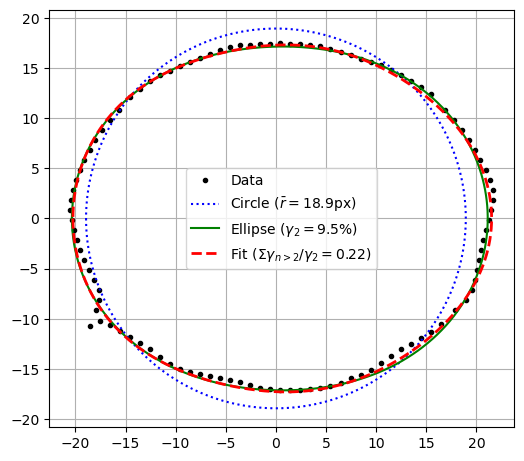

In [11]:
Fcoeff, cpos, rbar = da.fit_edge(drop_edges, filter_r_thr=filter_r_thr)

Now do that for all frames and all particles

In [12]:
defdf_savepath = os.path.join(froot, img_name+'_def.csv')
force_def = False
if os.path.isfile(defdf_savepath) and not force_def:
    print('csv filename with deformation result already present: skip deformation calculation')
    track_df = pd.read_csv(defdf_savepath)
    PID_sel = track_df['particle'].unique()
else:
    def_res, PID_sel = da.analyze_deformations(fpath, track_df, crop_roi_size=roi_size, img_bkg=bkg, img_bkgcorr_offset=bkgcorr_off, 
                                               img_blur_sigma=edge_blur, edge_threshold=edge_thr, smoothing_iterN=edge_iterN, 
                                               dbscan_eps=dbscan_eps, dbscan_minN=1, filter_r_thr=filter_r_thr, 
                                               plot_outdir=os.path.join(froot, 'out_tmp'), px_size=px_size, fps=fps)
    track_df.to_csv(os.path.join(froot, img_name+'_def.csv'))
track_df

csv filename with deformation result already present: skip track calculation


,Unnamed: 0.1,Unnamed: 0,y,x,mass,size,ecc,signal,raw_mass,ep,...,rbar,gamma1,gamma2,gamma3,gamma4,gamma5,xfit,yfit,vx,dvdx
0,0,18,189.310742,188.652477,10116.856516,8.447079,0.122245,37.144499,126676.0,NaN,...,18.000949,0.162105,0.091561,-0.000105,-0.005658,-0.010286,184.325588,190.479966,NaN,NaN
1,1,14,189.536826,213.375469,9495.933606,8.217760,0.102693,35.253561,125941.0,NaN,...,18.146488,0.147169,0.082294,0.001623,-0.009506,-0.013503,209.032068,190.474836,72205.0,NaN
2,2,15,189.830579,238.631432,9491.631643,8.158464,0.099042,36.119046,126259.0,NaN,...,17.745880,0.182673,0.043357,-0.024191,-0.026924,-0.026608,233.111913,190.488847,72205.0,0.000000
3,3,16,190.060962,264.803371,9639.764696,8.102073,0.105718,37.801639,126584.0,NaN,...,18.150882,0.170387,0.051561,-0.010750,-0.016546,-0.017711,260.145746,190.336811,75093.2,158.692308
4,4,18,190.312010,291.091378,9567.245967,8.101653,0.124746,37.759234,126644.0,NaN,...,14.003381,0.135404,0.185601,0.298241,-0.055391,0.010013,283.288735,199.988903,77981.4,152.814815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1178,1178,21,188.100208,962.048792,9950.125186,7.170646,0.041082,47.873244,122480.0,0.019420,...,17.125433,0.122460,0.079295,0.009325,-0.001924,-0.004683,959.450504,189.267888,80869.6,294.714286
1179,1179,16,187.790632,989.498368,9888.408971,7.157224,0.063628,48.986756,121940.0,NaN,...,16.996508,0.158126,0.051645,0.005916,-0.005416,-0.001460,986.161354,189.398078,77981.4,-152.814815
1180,1180,17,187.477059,1016.848818,9965.849097,7.153757,0.087467,49.136517,122423.0,0.038774,...,17.271887,0.112846,0.040625,0.002870,-0.004345,-0.002139,1014.593171,188.581765,77981.4,0.000000
1181,1181,18,187.190679,1043.514943,9948.167584,7.185721,0.130596,50.308036,122284.0,0.032458,...,12.535882,0.264320,0.106800,0.304047,-0.022089,-0.090985,1035.324694,180.395812,77981.4,0.000000


exclude particles: [739, 838, 855, 1026, 1220, 1284]


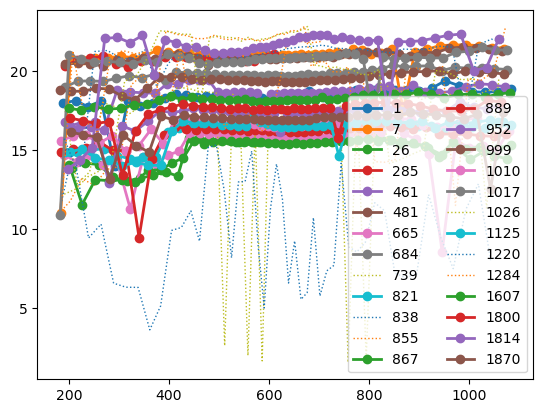

In [55]:
thr_relstd = 0.1

pID_subset = []
pID_excl = []
fig, ax = plt.subplots()
for pID in PID_sel:
    cur_subdf = track_df[(track_df['particle'] == pID)]
    if np.std(cur_subdf['rbar'])/np.mean(cur_subdf['rbar']) > thr_relstd:
        fmt = ':'
        lw=1
        pID_excl.append(int(pID))
    else:
        fmt = 'o-'
        lw=2
        pID_subset.append(int(pID))
    ax.plot(cur_subdf['x'], cur_subdf['rbar'], fmt, lw=lw, label=str(pID))
ax.legend(ncol=2)

print('exclude particles: ' + str(pID_excl))

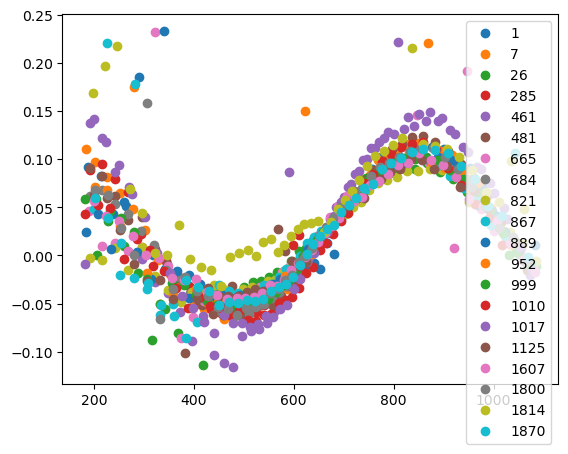

In [56]:
fig, ax = plt.subplots()
for pID in pID_subset:
    cur_subdf = track_df[(track_df['particle'] == pID)]
    ax.plot(cur_subdf['x'], cur_subdf['gamma2'], 'o', label=str(pID))
ax.legend()

In [19]:
pID_subset

[]